## Language Detection Model for Multilingual Text


In [254]:
# import all the required libraries for this project.

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import pickle

#import langdetect for language detection
from langdetect import detect

#remove warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [255]:
# load the dataset from a csv file for further processing.
df = pd.read_csv('language_detection_dataset.csv')

In [256]:
# showing the maximum number of rows and columns in the dataset to easily analyze the dataset.
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [257]:
#checking the first 5 rows of the dataset
df.head()

,Text,Language
0,"Nature, in the broadest sense, is the natural...",English
1,"""Nature"" can refer to the phenomena of the phy...",English
2,"The study of nature is a large, if not the onl...",English
3,"Although humans are part of nature, human acti...",English
4,[1] The word nature is borrowed from the Old F...,English


In [258]:
#checking the shape of the dataset
print("The shape of the dataset is:", df.shape)

The shape of the dataset is: (10337, 2)


In [259]:
# checking the missing values in the dataset
print("Missing values in the dataset:\n", df.isnull().sum())

#checking the duplicate values in the dataset
print("Duplicate values in the dataset:", df.duplicated().sum())

Missing values in the dataset:
 Text        0
Language    0
dtype: int64
Duplicate values in the dataset: 66


In [260]:
# since we got 66 duplicate values in the dataset, lets check those duplicate values in the dataset.
duplicate_rows = df[df.duplicated()]
print("Duplicate rows in the dataset:\n", duplicate_rows)


Duplicate rows in the dataset:
                                                     Text    Language
1141                                          i'm sorry.     English
1180                                          oh my god.     English
1196                                          i'm sorry.     English
1724                                 എന്നോട് ക്ഷമിക്കൂ.   Malayalam
1767                                      ഓ എന്റെ ദൈവമേ.   Malayalam
1783                                 എന്നോട് ക്ഷമിക്കൂ.   Malayalam
2013                                     कैसा चल रहा है?       Hindi
2219                               அது எப்படி நடக்கிறது?       Tamil
2258                                 என்னை மன்னிக்கவும்.       Tamil
2300                                             கடவுளே.       Tamil
2317                                 என்னை மன்னிக்கவும்.       Tamil
2438                                        மிக்க நன்றி.       Tamil
3003                                     Eu sinto Muito.  Portugeese
30

In [261]:
# for better model training, we will remove the duplicate values from the dataset.
df = df.drop_duplicates()


In [262]:
# and now we will again check the dataset for duplicates
print("Duplicate values in the dataset after removing duplicates:", df.duplicated().sum())

Duplicate values in the dataset after removing duplicates: 0


In [263]:
# lets check the information of the dataset to understand the data types of the features and target variable.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10271 entries, 0 to 10336
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      10271 non-null  object
 1   Language  10271 non-null  object
dtypes: object(2)
memory usage: 240.7+ KB


In [264]:
# lets check the statistical summary of the dataset to understand the distribution of the data.
df.describe()

,Text,Language
count,10271,10271
unique,10267,17
top,suggestions.,English
freq,2,1382


In [265]:
# since we came to know that the dataset has 17 languages, lets check the name of those languages and their count in the dataset.
print("Languages in the dataset and their count:\n", df['Language'].value_counts())

Languages in the dataset and their count:
 Language
English       1382
French        1007
Spanish        816
Portugeese     736
Italian        694
Russian        688
Sweedish       673
Malayalam      591
Dutch          542
Arabic         532
Turkish        471
German         465
Tamil          464
Danish         424
Kannada        366
Greek          358
Hindi           62
Name: count, dtype: int64


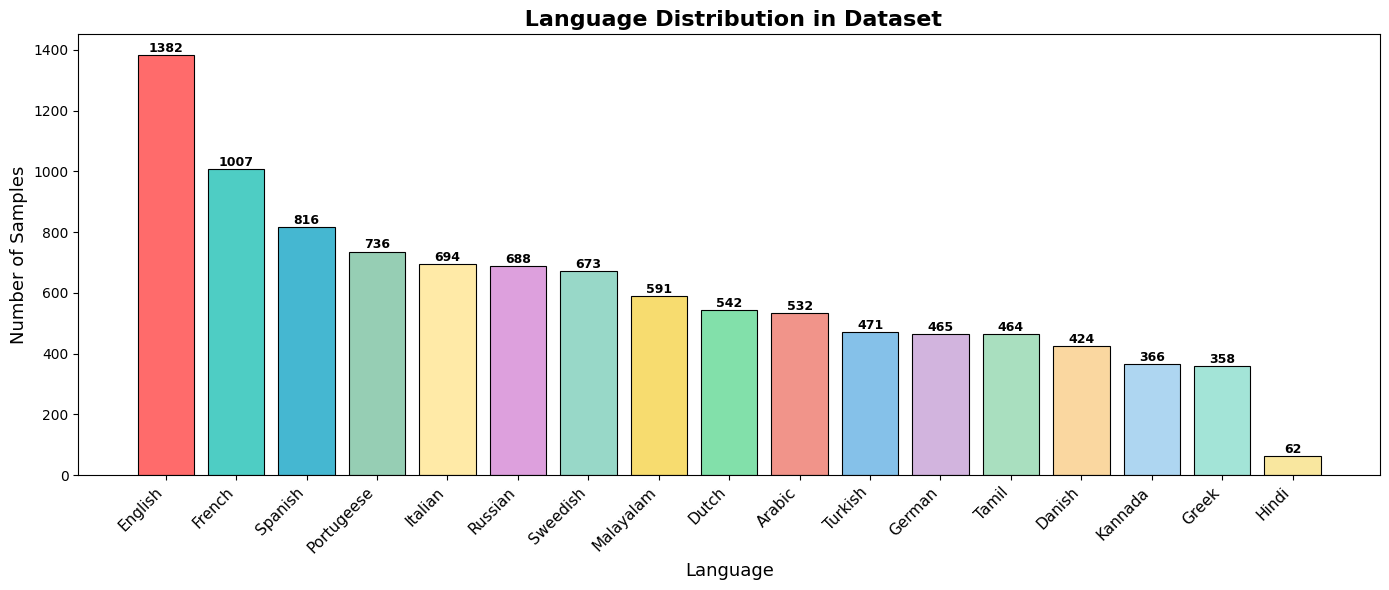

✅ Chart saved → language_distribution.png


In [266]:
plt.figure(figsize=(14, 6))

colors = [
    '#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7',
    '#DDA0DD','#98D8C8','#F7DC6F','#82E0AA','#F1948A',
    '#85C1E9','#D2B4DE','#A9DFBF','#FAD7A0','#AED6F1',
    '#A3E4D7','#F9E79F'
]

counts = df['Language'].value_counts()
bars   = plt.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.8)

plt.title(' Language Distribution in Dataset', fontsize=16, fontweight='bold')
plt.xlabel('Language', fontsize=13)
plt.ylabel('Number of Samples', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=11)

# Add count labels on top of bars
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10,
             str(count), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('language_distribution.png', dpi=150)
plt.show()
print("✅ Chart saved → language_distribution.png")

In [267]:
# now for further processing, we will split the dataset into features and target variable.
X = df['Text']
y = df['Language']

In [268]:
#check the shape of the features and target variable
print("Shape of features (X):", X.shape)
print("Shape of target variable (y):", y.shape)

Shape of features (X): (10271,)
Shape of target variable (y): (10271,)


In [269]:
#check the 10 samples rows of y to see the target variable
print("First 5 rows of target variable (y):\n", y.sample(10))

First 5 rows of target variable (y):
 5840         Greek
9900        German
4522         Dutch
8203       Turkish
8043       Turkish
3140    Portugeese
1062       English
6280       Russian
860        English
8993        Arabic
Name: Language, dtype: object


In [270]:
# check the 10 sample rows of X to see the features variable
print("First 5 rows of features variable (X):\n", X.sample(10))

First 5 rows of features variable (X):
 9682                            Ohne dich wäre es besser.
2084    தவிர, ஆரம்பத்தில் வேறு சில விதிமுறைகள் மட்டுமே...
8949    här prova några gyllene potatis de är riktigt ...
4225    ma chère enfant tu es si belle et adorable mai...
9008    [35] في كانون الثاني (يناير) 2007، دخلت ويكيبي...
8068    Birine gülümsemesini söylemek için benimle dal...
839     In the mathematical model, each training examp...
3263    Phuein, c'est l'éclosion, ce qui se manifeste ...
3522    Aucun article n'est considéré comme achevé, et...
7662                            fammi pensare un momento.
Name: Text, dtype: object


### preprocessing and model training

In [271]:
import unicodedata 
'''
 unicode assigns a unique code to every character, no matter the platform, program, or language. 
 This allows us to handle text in a consistent way across different languages and scripts.
'''
def preprocess_text(text):
    """
    Safe preprocessing that preserves ALL language specific characters.
    Works for Arabic, Hindi, Tamil, Malayalam, Kannada, Russian, Greek etc.
    """
    if not isinstance(text, str):
        return ""

    # Normalize unicode — keeps all characters intact
    text = unicodedata.normalize('NFC', text)

    # Lowercase — only affects Latin script, safe for all others
    text = text.lower()

    # Remove control characters only
    text = re.sub(r'[\x00-\x1f\x7f]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [272]:
# Apply preprocessing
df['Text'] = df['Text'].apply(preprocess_text)

print("Preprocessing complete!")
print("\nSample After preprocessing:")
print(df[['Text','Language']].head(10).to_string())

Preprocessing complete!

Sample After preprocessing:
                                                                                                                                                                                                                                                                                                                                      Text Language
0                                                                                                                                                                                                                                                     nature, in the broadest sense, is the natural, physical, material world or universe.  English
1                                                                                                                                                                                                                                                  "nature" can refer to th

In [273]:
# convert the target variable into numerical values using label encoding for better model training.
label_encoder = LabelEncoder()
df['Language'] = label_encoder.fit_transform(df['Language'])


In [274]:
# checking the encoded target variable to see which number is assigned to which language.
encoded_labels = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Encoded labels (Language → Numeric):\n", encoded_labels)

Encoded labels (Language → Numeric):
 {'Arabic': np.int64(0), 'Danish': np.int64(1), 'Dutch': np.int64(2), 'English': np.int64(3), 'French': np.int64(4), 'German': np.int64(5), 'Greek': np.int64(6), 'Hindi': np.int64(7), 'Italian': np.int64(8), 'Kannada': np.int64(9), 'Malayalam': np.int64(10), 'Portugeese': np.int64(11), 'Russian': np.int64(12), 'Spanish': np.int64(13), 'Sweedish': np.int64(14), 'Tamil': np.int64(15), 'Turkish': np.int64(16)}


In [275]:
# import it into pkl file for later use in the model training and evaluation.
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

In [276]:
# now train test split the dataset into training and testing sets for model training and evaluation.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

Training samples: 8216
Test samples: 2055


In [277]:
# creating a pipeline for all three models to see which model performs best on this dataset.
# we will use TfidfVectorizer for feature extraction and MultinomialNB, LogisticRegression, SVC for model training and evaluation.

models = {
    # using navie byes with character n-grams (2 to 4) for better performance on short texts and multilingual data.
    "Naive Bayes": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer='char', ngram_range=(2,4))),
        ("model", MultinomialNB())
    ]),
    # using logistic regression with character n-grams (2 to 4) for better performance on short texts and multilingual data.
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer='char', ngram_range=(2,4))),
        ("model", LogisticRegression(max_iter=200))
    ]),
    #using support vector classifier with character n-grams (2 to 4) for better performance on short texts and multilingual data.
    "SVM": Pipeline([
        ("tfidf", TfidfVectorizer(analyzer='char', ngram_range=(2,4))),
        ("model", SVC())
    ])
}

In [278]:
# this step will show us the probability score of two models.
best_prob_model = None
best_prob_score = 0

In [279]:
# storing the result of each model in a dictionary to compare the performance of each model and select the best model based on accuracy score.
results = {}
best_model = None
best_score = 0
best_name = ""

for name, pipeline in models.items():
    print(f"\nTraining {name}...")
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
    # Select best model
    if acc > best_score:
        best_score = acc
        best_model = pipeline
        best_name = name

        # Best model WITH probability support
    if hasattr(pipeline.named_steps['model'], "predict_proba"):
        if acc > best_prob_score:
            best_prob_score = acc
            best_prob_model = pipeline

print("\n✅ Best Model:", best_name)
print("✅ Best Accuracy:", best_score)


Training Naive Bayes...
Naive Bayes Accuracy: 0.9397
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       106
      Danish       1.00      0.64      0.78        85
       Dutch       0.99      0.73      0.84       108
     English       0.72      1.00      0.84       277
      French       0.99      0.99      0.99       202
      German       1.00      0.72      0.84        93
       Greek       1.00      1.00      1.00        72
       Hindi       1.00      1.00      1.00        12
     Italian       1.00      0.94      0.97       139
     Kannada       1.00      1.00      1.00        73
   Malayalam       1.00      1.00      1.00       118
  Portugeese       0.99      0.97      0.98       147
     Russian       1.00      0.99      0.99       138
     Spanish       0.98      0.98      0.98       163
    Sweedish       0.93      0.92      0.92       135
       Tamil       1.00      1.00      1.00        93
     Turkish       1.00    

#### since logistics regression works well as cmpared to other so we will use logistics regreesion for further working

In [280]:
def predict_top2(text):
    processed = preprocess_text(text)

    if hasattr(model.named_steps['model'], "predict_proba"):
        probs = model.predict_proba([processed])[0]
        classes = model.named_steps['model'].classes_

        top2_idx = np.argsort(probs)[-2:][::-1]

        return [
            (classes[top2_idx[0]], probs[top2_idx[0]]),
            (classes[top2_idx[1]], probs[top2_idx[1]])
        ]

In [ ]:
pred = model.predict([processed])[0]
language = pred   # NO encoder

In [281]:
# save the best model into a pkl file for later use in the model deployment.
with open('language_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

In [282]:
#save the tfidf vectorizer separately for later use in the model deployment.
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(best_model.named_steps['tfidf'], f)

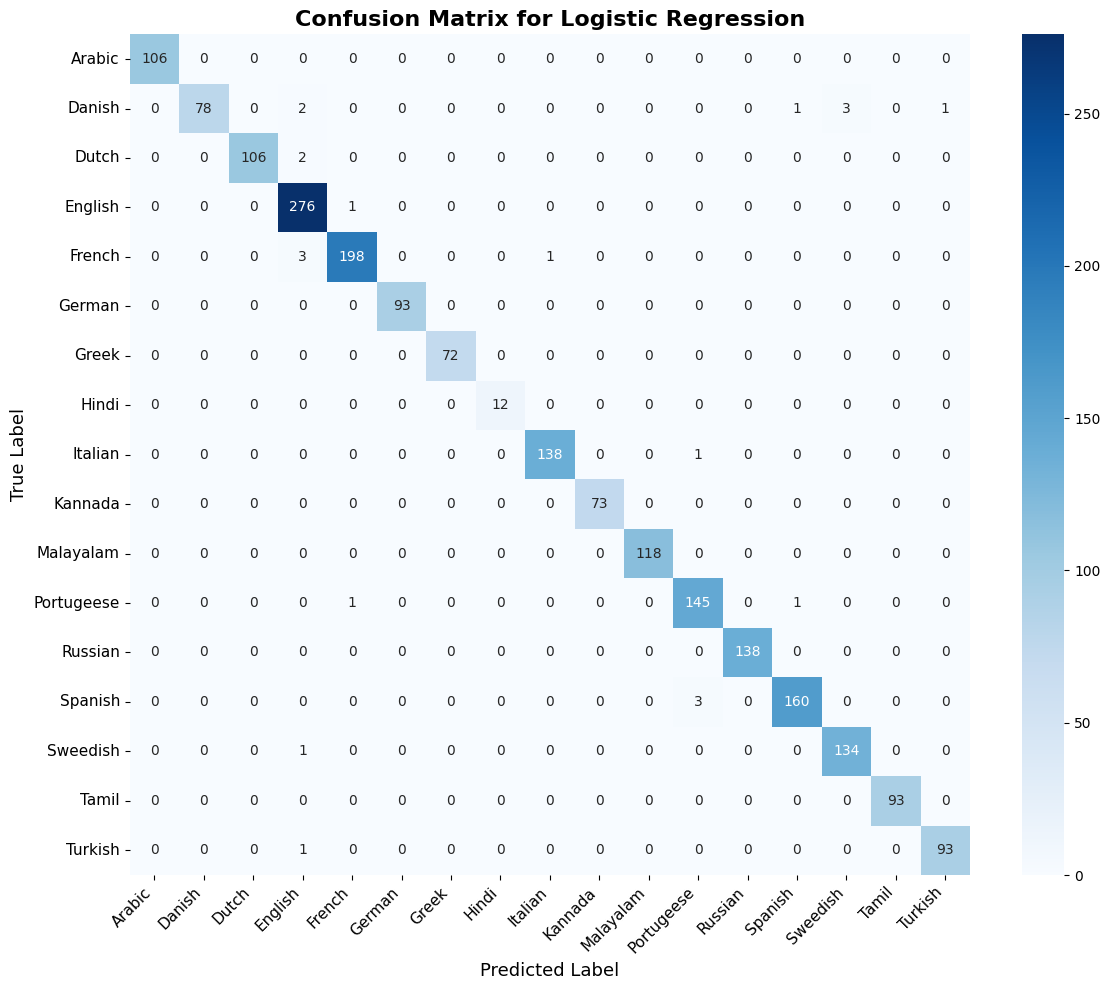

✅ Confusion matrix saved → Logistic Regression_confusion_matrix.png


In [283]:
# create heatmap for confusion matrix of the best model to visualize the performance of the best model on the test set.
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix for {best_name}', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()
print(f"✅ Confusion matrix saved → {best_name}_confusion_matrix.png")


In [284]:
# comparison between language detection model and langdetect library for language detection on the test set.

def compare_models(text):
    text_clean = preprocess(text)
    
    # Your model
    my_prediction = best_model.predict([text_clean])[0]
    
    # Langdetect prediction
    try:
        langdetect_prediction = detect(text)
    except:
        langdetect_prediction = "Error detecting"
    
    print("\n🔍 Comparison:")
    print("Your Model:", my_prediction)
    print("Langdetect:", langdetect_prediction)

In [285]:
def compare_models(text):
    text_clean = preprocess(text)
    
    my_prediction = best_model.predict([text_clean])[0]
    
    try:
        ld_pred = detect(text)
        ld_pred_full = lang_map.get(ld_pred, ld_pred)
    except:
        ld_pred_full = "Error"
    
    print("\n🔍 Comparison:")
    print("Your Model:", my_prediction)
    print("Langdetect:", ld_pred_full)

In [286]:
def full_analysis(text):
    print("\nInput:", text)
    
    # Top-2
    predict_top2(text)
    
    # Comparison
    compare_models(text)

In [290]:
# alias to match functions that call preprocess(...)
preprocess = preprocess_text

# use the best available trained pipeline for prediction
model = best_prob_model or best_model

# avoid NameError in compare_models()
lang_map = {}

full_analysis("Cómo estás")


Input: Cómo estás

🔍 Comparison:
Your Model: Spanish
Langdetect: es


In [291]:
# adding a function for batch/CSV input for language detection using the best model and langdetect library for comparison.
import pandas as pd

def batch_predict(input_file, output_file):
    try:
        df = pd.read_csv(input_file)
    except Exception as e:
        print("❌ Error loading file:", e)
        return

    if "Text" not in df.columns:
        print("❌ CSV must contain 'Text' column")
        return

    predictions = []
    top1_probs = []
    top2_labels = []
    top2_probs = []
    langdetect_preds = []

    for text in df["Text"]:
        processed = preprocess_text(text)

        # ===== Your Model Prediction =====
        pred = model.predict([processed])[0]
        language = label_encoder.inverse_transform([pred])[0]
        predictions.append(language)

        # ===== Probability (Top-2) =====
        if hasattr(model.named_steps['model'], "predict_proba"):
            probs = model.predict_proba([processed])[0]
            classes = model.named_steps['model'].classes_
            classes = label_encoder.inverse_transform(classes)

            top2_idx = np.argsort(probs)[-2:][::-1]

            top1_probs.append(probs[top2_idx[0]])
            top2_labels.append(classes[top2_idx[1]])
            top2_probs.append(probs[top2_idx[1]])
        else:
            top1_probs.append(None)
            top2_labels.append(None)
            top2_probs.append(None)

        # ===== Langdetect =====
        try:
            ld = detect(text)
            ld = lang_map.get(ld, ld)
        except:
            ld = "Error"

        langdetect_preds.append(ld)

    # ===== Add Columns =====
    df["Predicted_Language"] = predictions
    df["Top1_Confidence"] = top1_probs
    df["Second_Language"] = top2_labels
    df["Second_Confidence"] = top2_probs
    df["Langdetect"] = langdetect_preds

    # ===== Save Output =====
    df.to_csv(output_file, index=False)

    print(f"\n✅ Batch prediction completed!")
    print(f"📁 Output saved to: {output_file}")